In [ ]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
import tensorflow as tf
import shap
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load and preprocess data
data = pd.read_csv('/content/drive/MyDrive/creditcard.csv')
data.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
data = data.sort_values(by='Time')
data['Time_Diff'] = data['Time'].diff().fillna(0)

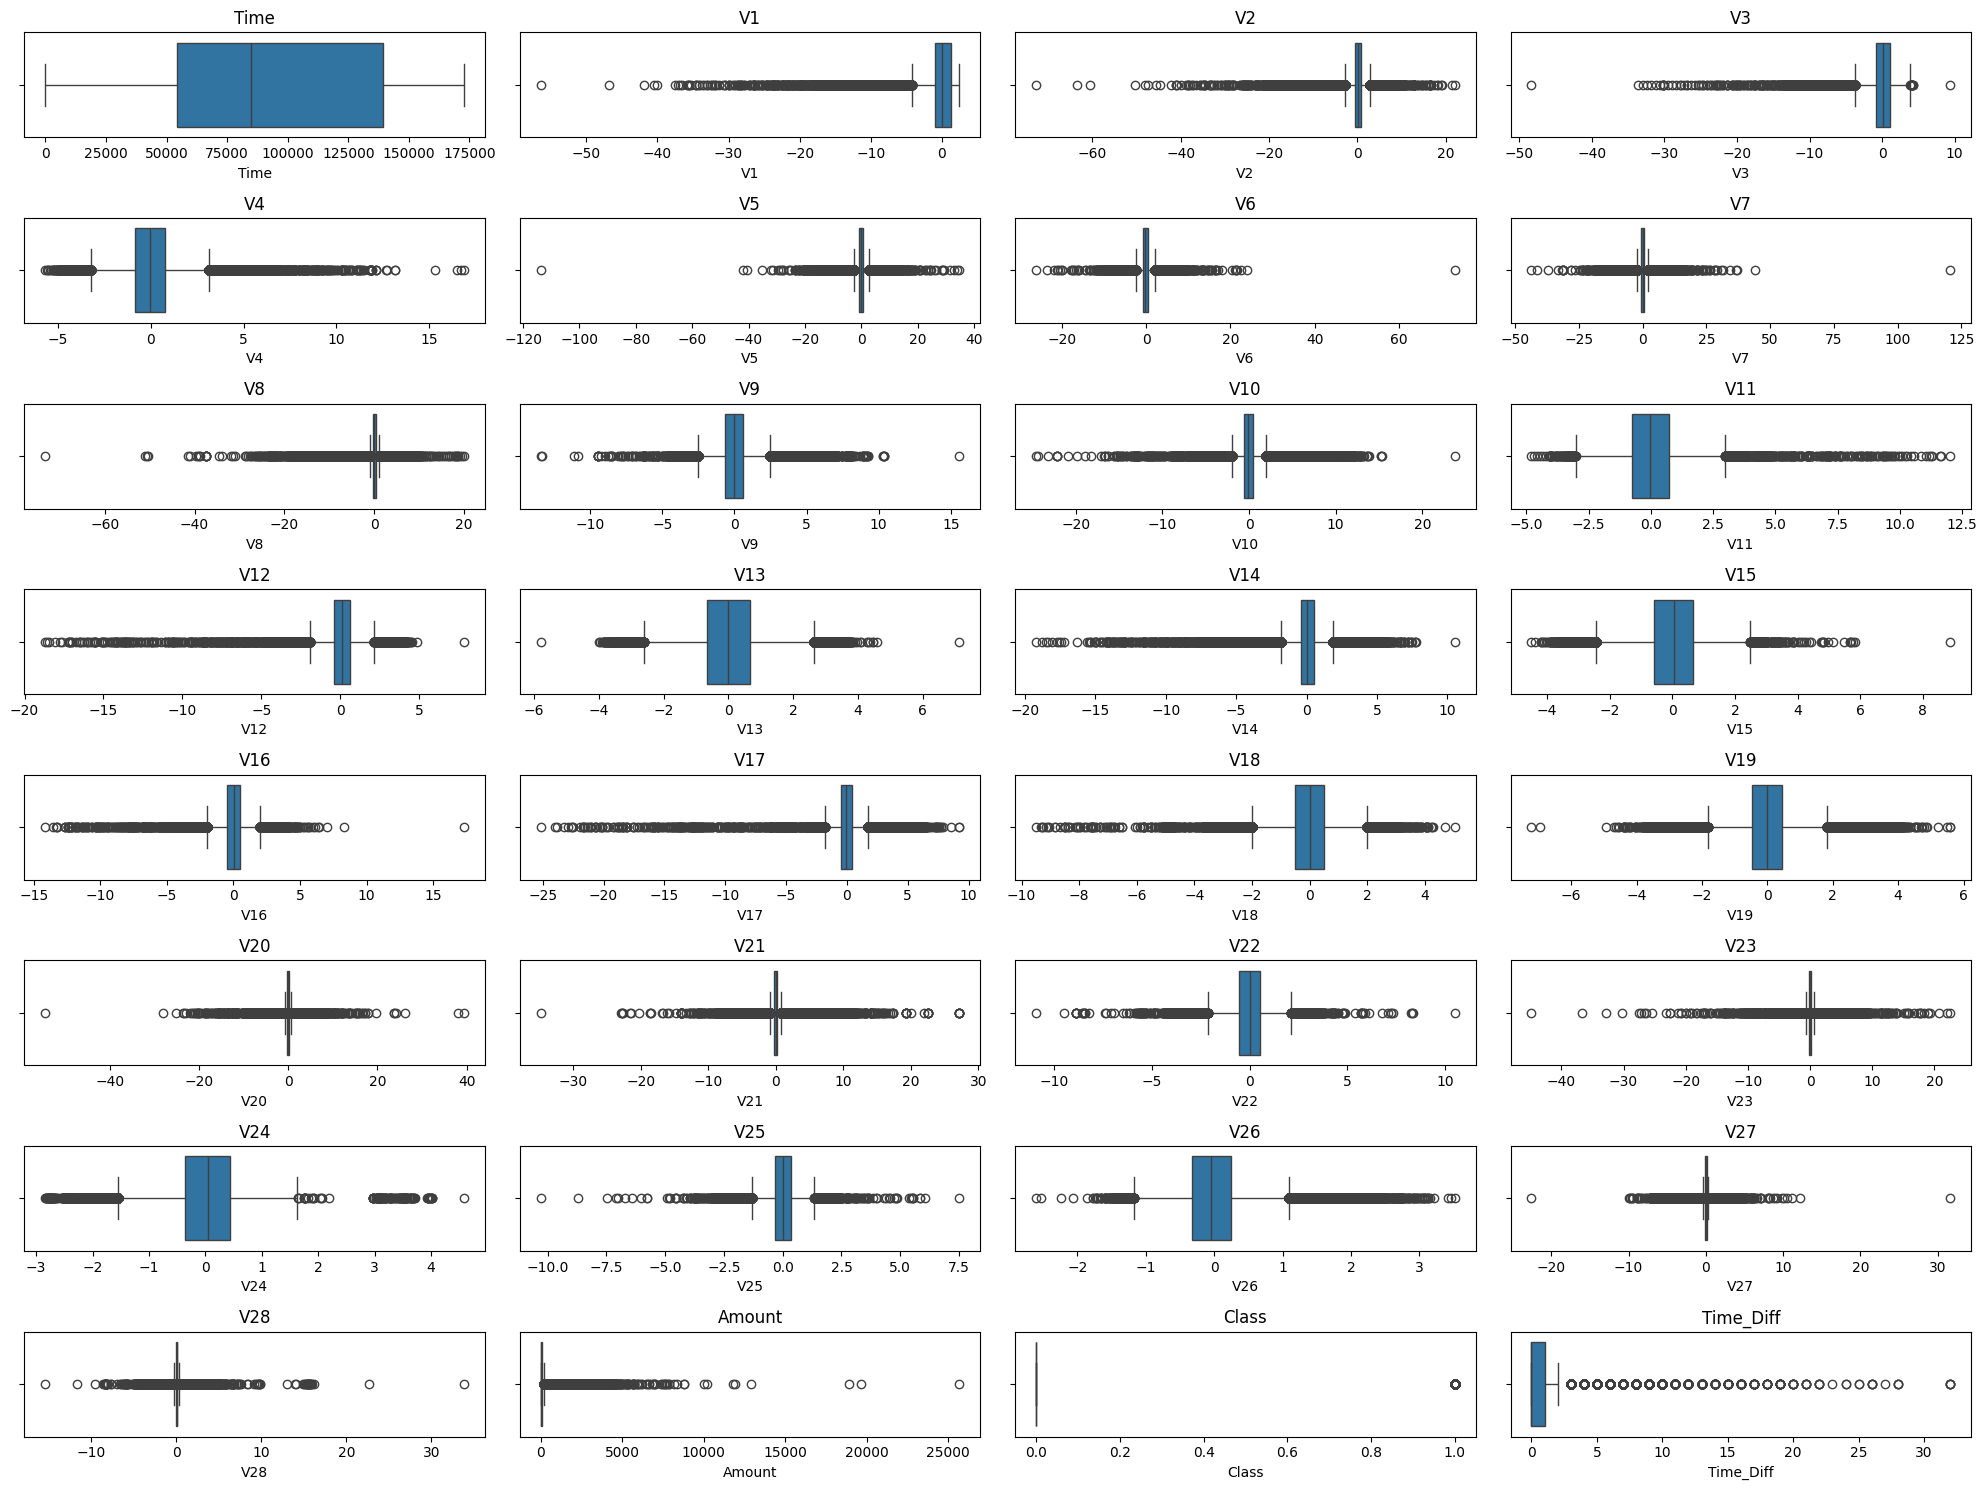

In [ ]:
plt.figure(figsize=(20, 15))
#for idk,col in enumerate(data.columns):
i=1
for col in data.columns:
    plt.subplot(8,4,i)
    sns.boxplot(data=data, x=col)
    plt.title(col)
    i+=1
plt.tight_layout()
plt.show()

In [ ]:
X = data.drop('Class', axis=1)
y = data['Class']

In [ ]:
y.info()

<class 'pandas.core.series.Series'>
Index: 284807 entries, 0 to 284806
Series name: Class
Non-Null Count   Dtype
--------------   -----
284807 non-null  int64
dtypes: int64(1)
memory usage: 4.3 MB


Original training set class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64
Resampled training set class distribution:
 Class
0    284315
1    284315
Name: count, dtype: int64


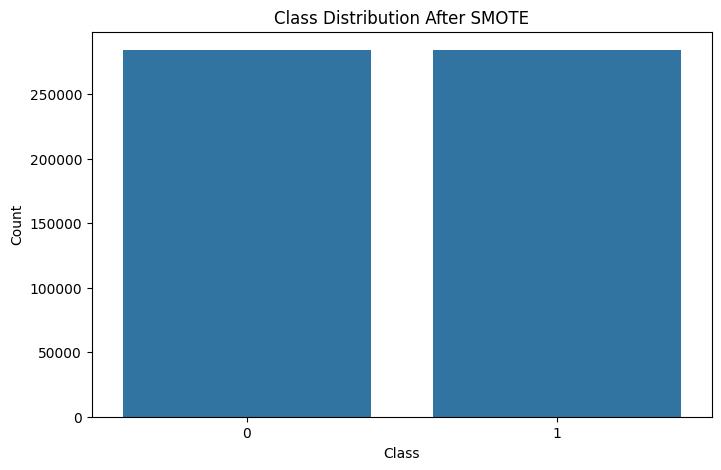

In [ ]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X, y)

print("Original training set class distribution:\n", y.value_counts())
print("Resampled training set class distribution:\n", y_train_resampled.value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_resampled)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42, stratify=y_train_resampled)


In [ ]:
# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [ ]:
# Sample for SHAP (to speed up computation)
X_train_sample = X_train[np.random.choice(X_train.shape[0], 1000, replace=False)]

In [ ]:
#train Neural Network
nn_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Define and train all models
models = {
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'Neural Network': nn_model,
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100),
}

results = {}
predictions = {}

for name, model in models.items():
    if name == 'Neural Network':
        y_pred_proba = model.predict(X_test).flatten()
        y_pred = (y_pred_proba > 0.5).astype(int)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    predictions[name] = y_pred_proba
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:54:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


3554/3554 ━━━━━━━━━━━━━━━━━━━━ 4s 992us/step


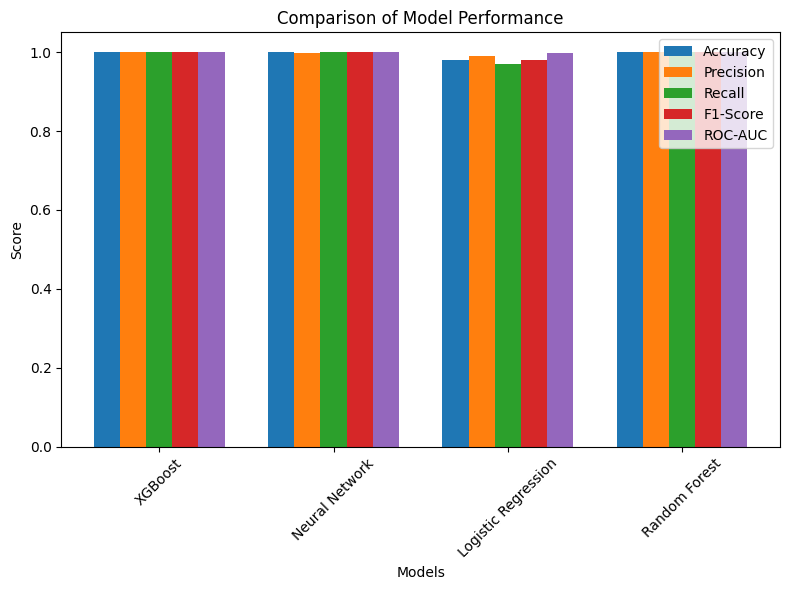

                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
XGBoost              0.999833   0.999684  0.999982  0.999833  0.999995
Neural Network       0.998989   0.997999  0.999982  0.998990  0.999933
Logistic Regression  0.980251   0.990358  0.969945  0.980045  0.997513
Random Forest        0.999868   0.999736  1.000000  0.999868  0.999999


In [ ]:
# Compare models with visualization
results_df = pd.DataFrame(results).T

# Plot comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plt.figure(figsize=(8, 6))
bar_width = 0.15
index = np.arange(len(models))

for i, metric in enumerate(metrics):
    plt.bar(index + i * bar_width, results_df[metric], bar_width, label=metric)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Comparison of Model Performance')
plt.xticks(index + bar_width * 2, results_df.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print(results_df)

Best model based on ROC-AUC: Random Forest
Accuracy     0.999868
Precision    0.999736
Recall       1.000000
F1-Score     0.999868
ROC-AUC      0.999999
Name: Random Forest, dtype: float64


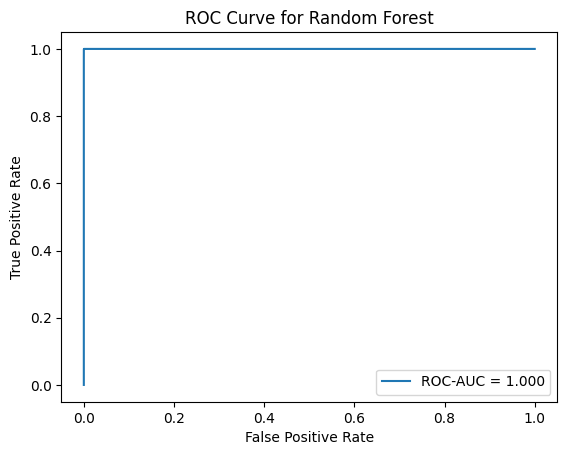

In [ ]:
# Select the best model based on ROC-AUC
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = models[best_model_name]
print(f"Best model based on ROC-AUC: {best_model_name}")
print(results_df.loc[best_model_name])

# Get predictions
y_pred_proba = predictions[best_model_name]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title(f'ROC Curve for {best_model_name}')
plt.show()

Best model: Random Forest
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (100, 31, 2)
Max absolute SHAP value: 0.3064314877412709
Min absolute SHAP value: 2.927346182810069e-06


<Figure size 800x500 with 0 Axes>

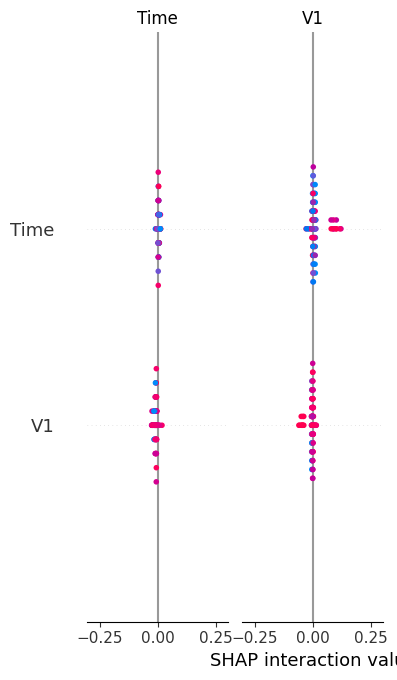

In [ ]:
#Apply SHAP to the best model
if best_model_name in ['XGBoost', 'Random Forest']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test[:100])
elif best_model_name == 'Neural Network':
    background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]
    explainer = shap.KernelExplainer(best_model.predict, background)
    shap_values = explainer.shap_values(X_test[:100])
else:  # Logistic Regression
    background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]
    explainer = shap.KernelExplainer(lambda x: best_model.predict_proba(x)[:, 1], background)
    shap_values = explainer.shap_values(X_test[:100])

# Enhanced Debugging
print(f"Best model: {best_model_name}")
print(f"SHAP values type: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"SHAP values is a list with {len(shap_values)} elements")
    for i, val in enumerate(shap_values):
        print(f"  Element {i} shape: {np.array(val).shape}")
else:
    print(f"SHAP values shape: {np.array(shap_values).shape}")

# Handle different SHAP value structures
if best_model_name in ['XGBoost', 'Random Forest']:
    if isinstance(shap_values, list):

        shap_values_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:

        shap_vals_array = np.array(shap_values)
        if len(shap_vals_array.shape) == 3:
            shap_values_to_plot = shap_vals_array[:, :, 1]
            shap_values_to_plot = shap_vals_array  # Single output
elif best_model_name in ['Neural Network', 'Logistic Regression']:
    shap_vals_array = np.array(shap_values)
    if len(shap_vals_array.shape) == 3:
        shap_values_to_plot = shap_vals_array[:, :, 1]  # Fraud class
    else:
        shap_values_to_plot = shap_vals_array  # Single output
else:
    shap_values_to_plot = shap_values  # Fallback

# Additional check: Are SHAP values meaningful?
print(f"Max absolute SHAP value: {np.max(np.abs(shap_values_to_plot))}")
print(f"Min absolute SHAP value: {np.min(np.abs(shap_values_to_plot))}")

# SHAP Summary Plot
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_to_plot, X_test[:100], feature_names=X.columns, plot_type='bar')


Waterfall plot for fraud sample index: 0
SHAP values shape: (100, 31, 2)


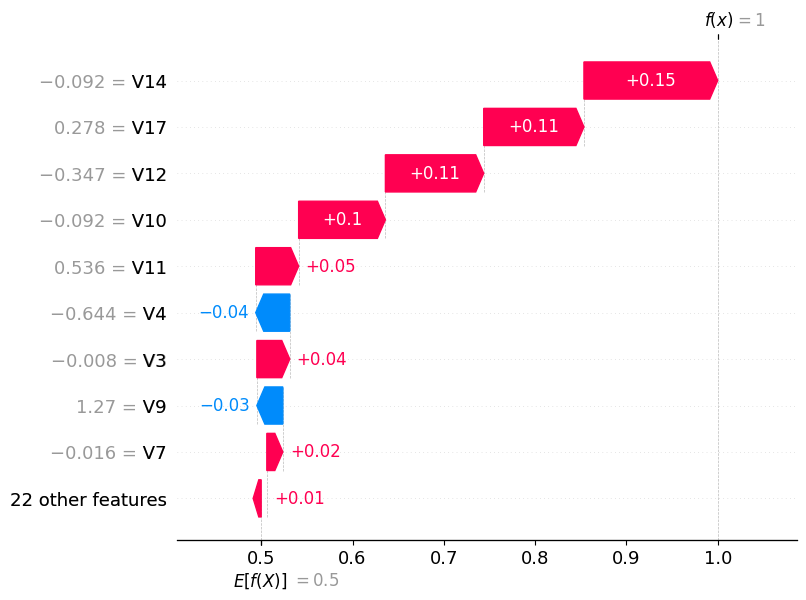

In [ ]:
# Waterfall plot for a fraud sample (robust version)
fraud_indices = np.where(y_test[:100] == 1)[0]
if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    print(f"Waterfall plot for fraud sample index: {fraud_idx}")
    print(f"SHAP values shape: {np.array(shap_values).shape}")

    # Handle SHAP values based on model type and shape
    if best_model_name in ['XGBoost', 'Random Forest']:
        shap_vals_array = np.array(shap_values)
        if len(shap_vals_array.shape) == 3:
            shap_values_single = shap_vals_array[fraud_idx, :, 1]  # Fraud class
        else:  # (n_samples, n_features)
            shap_values_single = shap_vals_array[fraud_idx]
        base_value = explainer.expected_value[1]  # Fraud class
    else:  # Neural Network or Logistic Regression
        shap_vals_array = np.array(shap_values)
        if len(shap_vals_array.shape) == 3:
            shap_values_single = shap_vals_array[fraud_idx, :, 1]  # Fraud class
        else:
            shap_values_single = shap_vals_array[fraud_idx]
        base_value = explainer.expected_value[1]  # Fraud class

    shap.waterfall_plot(shap.Explanation(
        values=shap_values_single,
        base_values=base_value,
        data=X_test[fraud_idx],
        feature_names=X.columns.tolist()
    ))
else:
    print("No fraud sample found in the first 100 test samples.")

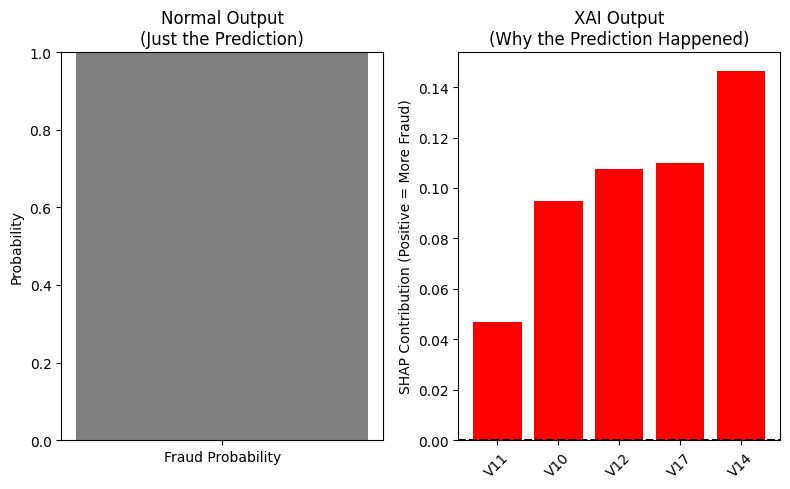

Sample Index: 0
Fraud Probability: 1.0000
Top 5 Features and SHAP Contributions:
  - V11: increased fraud likelihood by 0.0470
  - V10: increased fraud likelihood by 0.0950
  - V12: increased fraud likelihood by 0.1077
  - V17: increased fraud likelihood by 0.1098
  - V14: increased fraud likelihood by 0.1465


In [ ]:
# Simplified side-by-side bar plots for Normal vs Explainable ML (Random Forest)
import matplotlib.pyplot as plt

rf_model = models['Random Forest']
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


fraud_indices = np.where(y_test[:100] == 1)[0]
if len(fraud_indices) == 0:
    print("No fraud sample found in the first 100 test samples.")
    fraud_idx = 0
else:
    fraud_idx = fraud_indices[0]

normal_pred_value = y_pred_proba[fraud_idx]


shap_vals_single = shap_values[fraud_idx] if isinstance(shap_values, list) else shap_values[fraud_idx]
if isinstance(shap_vals_single, np.ndarray) and len(shap_vals_single.shape) > 1:
    shap_values_single = shap_vals_single[:, 1]
else:
    shap_values_single = shap_vals_single


top_features_idx = np.argsort(np.abs(shap_values_single))[-5:]
top_features = [(X.columns[i], shap_values_single[i]) for i in top_features_idx]


plt.figure(figsize=(8, 5))

# Left: Normal Output
plt.subplot(1, 2, 1)
plt.bar(['Fraud Probability'], [normal_pred_value], color='gray')
plt.ylim(0, 1)
plt.title('Normal Output\n(Just the Prediction)')
plt.ylabel('Probability')

# Right: XAI Output
plt.subplot(1, 2, 2)
features, values = zip(*top_features)
plt.bar(features, values, color=['red' if v > 0 else 'blue' for v in values])
plt.axhline(0, color='black', linestyle='--')
plt.xticks(rotation=45)
plt.title('XAI Output\n(Why the Prediction Happened)')
plt.ylabel('SHAP Contribution (Positive = More Fraud)')

plt.tight_layout()
plt.show()

# Print sample info for reference
print(f"Sample Index: {fraud_idx}")
print(f"Fraud Probability: {normal_pred_value:.4f}")
print("Top 5 Features and SHAP Contributions:")
for feature, value in top_features:
    effect = 'increased' if value > 0 else 'decreased'
    print(f"  - {feature}: {effect} fraud likelihood by {abs(value):.4f}")

<Figure size 600x600 with 0 Axes>

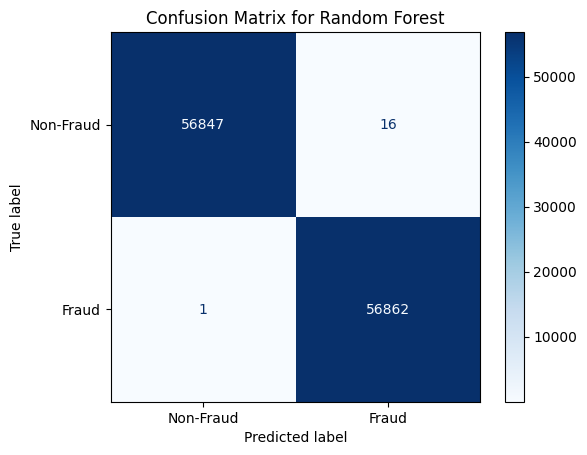

In [ ]:
# Final output with predictions and explanation
if best_model_name == 'Neural Network':
    final_pred = best_model.predict(X_test, verbose=0).flatten()
else:
    final_pred = best_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
final_pred_binary = (final_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, final_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud', 'Fraud'])
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix for {best_model_name}')
plt.show()


